# 01 — Data Understanding
Credit Card Fraud Detection (Kaggle: mlg-ulb/creditcardfraud)

Mục tiêu của notebook này: đọc dữ liệu, kiểm tra kiểu dữ liệu, missing values,
duplicate, outlier, và target distribution. Chưa xử lý.

In [1]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Kiểu dữ liệu (dtypes)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Kỳ vọng:** tất cả các cột (`Time`, `V1`-`V28`, `Amount`, `Class`) đều là kiểu số
(`float64` hoặc `int64`). Nếu có cột nào bị đọc thành `object` thì cần kiểm tra lại
(có thể do ký tự lạ, encoding, hoặc dấu phân cách sai).

## 2. Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

if missing_summary.empty:
    print("Không có missing value nào trong dataset.")
else:
    print(missing_summary)

Không có missing value nào trong dataset.


**Ghi chú:** bộ dữ liệu này vốn đã được làm sạch sẵn (dataset kinh điển cho benchmark),
nên khả năng cao sẽ không có missing value. Nếu chạy ra khác, đây là điểm cần xử lý
ưu tiên trước khi qua bước tiếp theo.

**Shape: 284,807 dòng × 31 cột (Time, V1–V28, Amount, Class)**

**Tất cả các cột đều là kiểu số (numeric), không có cột nào bị lỗi kiểu dữ liệu**

**Không có missing value**

## 3. Duplicate

In [5]:
n_dup = df.duplicated().sum()
print(f"Số dòng duplicate: {n_dup} ({n_dup/len(df)*100:.3f}%)")

# Xem thử vài dòng duplicate nếu có
if n_dup > 0:
    df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

Số dòng duplicate: 1081 (0.380%)


**1,081 dòng trùng lặp (0.38% tổng dữ liệu)**

**Xử lý: drop được, nhưng phải làm sau train/test split để tránh data leakage**

**Lưu ý quan trọng:** dataset này có duplicate thật (đã biết trước từ cộng đồng Kaggle,
tầm ~1.06% số dòng). Đây là điểm cần quyết định ở giai đoạn Data Cleaning: có nên
drop duplicate hay không, và nếu drop thì làm trước hay sau train/test split
(để tránh data leakage — một bản duplicate rơi vào cả train lẫn test).

## 4. Outlier (đặc biệt cột `Amount`)

In [6]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


Q1 = 5.6
Q3 = 77.16499999999999
IQR bounds: [-101.75, 184.51]
Số outlier theo IQR rule: 31904 (11.20%)


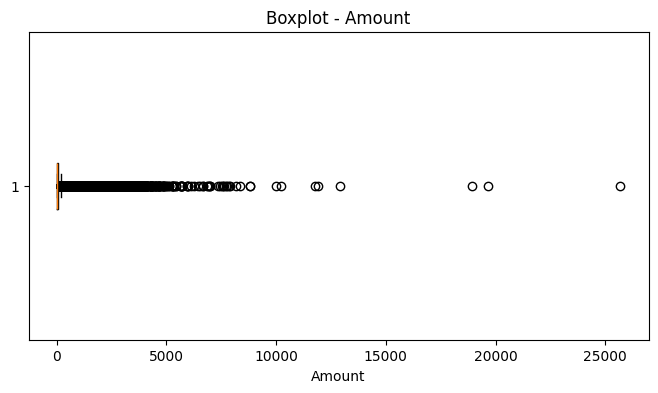

In [9]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

n_outliers = ((df['Amount'] < lower) | (df['Amount'] > upper)).sum()
print(f'Q1 = {Q1}\nQ3 = {Q3}')
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Số outlier theo IQR rule: {n_outliers} ({n_outliers/len(df)*100:.2f}%)")

plt.figure(figsize=(8, 4))
plt.boxplot(df['Amount'], vert=False)
plt.title('Boxplot - Amount')
plt.xlabel('Amount')
plt.show()

**Phân phối lệch phải mạnh (right-skewed): mean 88.3, nhưng max lên tới 25,691; Q3 chỉ 77.2**

**IQR rule gắn cờ 11.2% là outlier — nhưng đây là false alarm của IQR, không phải lỗi dữ liệu, vì IQR không phù hợp với phân phối lệch nặng**

**Quyết định: không loại bỏ các giá trị này (amount lớn có thể là tín hiệu fraud). Xử lý bằng log-transform hoặc RobustScaler ở bước Feature Engineering**

**Cẩn thận:** với bài toán fraud detection, "outlier" ở `Amount` không nhất thiết là
lỗi dữ liệu cần loại bỏ — giao dịch với số tiền bất thường có thể chính là fraud
(hoặc chính là feature quan trọng để phân biệt fraud). Nên **so sánh phân phối
Amount giữa Class=0 và Class=1** trước khi quyết định có xử lý outlier hay không —
xem ở bước tiếp theo.

## 5. Target distribution (`Class`)

        count  percent
Class                 
0      284315  99.8273
1         492   0.1727


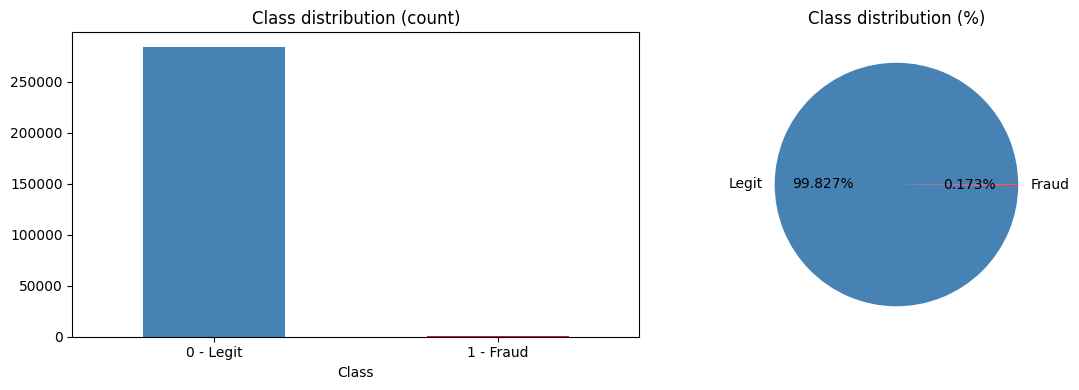

In [8]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': class_counts, 'percent': class_pct.round(4)})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Class distribution (count)')
axes[0].set_xticklabels(['0 - Legit', '1 - Fraud'], rotation=0)

axes[1].pie(class_counts, labels=['Legit', 'Fraud'], autopct='%1.3f%%', colors=['steelblue', 'crimson'])
axes[1].set_title('Class distribution (%)')
plt.tight_layout()
plt.show()

**Fraud: 0.173% (~492 dòng) vs Legit: 99.827%**

Tỷ lệ ~1:577 → extreme imbalance, không phải imbalance thông thường

**Hệ quả:**

Accuracy vô nghĩa làm metric (baseline "toàn bộ Legit" đã đạt 99.8%)

Bắt buộc stratify= khi split

Bắt buộc xử lý imbalance (SMOTE/undersampling/class_weight) — chỉ áp dụng lên tập train

Metric đánh giá chính: Precision, Recall, F1, PR-AUC (không phải ROC-AUC hay Accuracy)

- Không dùng Accuracy làm metric chính (đã nói ở business_understanding.md)
- Bắt buộc phải xử lý imbalance (SMOTE / undersampling / class_weight) ở Giai đoạn 2
- Train/test split **phải dùng `stratify=df['Class']`**, nếu không tỷ lệ fraud
  giữa train và test có thể lệch nhau đáng kể vì số lượng fraud quá ít

In [10]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


So sánh thống kê `Amount` giữa 2 class — xem fraud có xu hướng amount cao/thấp/khác
biệt rõ rệt so với giao dịch hợp lệ hay không. Đây là gợi ý sớm cho phần EDA sâu hơn
ở notebook `02_eda.ipynb`.

## 6. Kết luận (Data Understanding)

- Shape: `284,807 rows × 31 columns`

- Kiểu dữ liệu: tất cả numeric (`Time`, `V1`-`V28`, `Amount`, `Class`) — không có cột nào bị đọc sai kiểu dữ liệu.

- Missing values: không có.

- Duplicate: 1,081 dòng (0.38%) — quyết định drop **sau** khi train/test split
  (không phải trước), để tránh data leakage khi 1 bản duplicate rơi vào train
  và bản còn lại rơi vào test.

- Target distribution: fraud chỉ chiếm **0.173%** (492/284,807 dòng), tỷ lệ
  ~1:577 — xác nhận đây là bài toán **extreme imbalance**, không phải imbalance
  thông thường. Bắt buộc dùng `stratify=Class` khi split, và không dùng Accuracy làm metric đánh giá.

- Amount ở 2 class: có khác biệt — mean fraud (122.21) cao hơn mean legit
  (88.29), nhưng median fraud (9.25) lại thấp hơn nhiều so với median legit
  (22.00), cho thấy phân phối fraud lệch 2 cực (nhiều giao dịch rất nhỏ + vài
  giao dịch lớn) → gợi ý cần log-transform Amount ở bước Feature Engineering,
  và đào sâu thêm ở EDA (histogram/boxplot theo class).

**Hướng đi tiếp theo**

EDA sâu hơn (02_eda.ipynb): so sánh phân phối Amount, Time, V1-V28 giữa 2 class để tìm feature phân tách fraud/legit tốt nhất

Feature engineering: log-transform Amount, có thể trích xuất giờ trong ngày từ Time

Imbalance handling: so sánh SMOTE vs undersampling vs class_weight trên tập train